In [1]:
# Exponential Smoothing - Flattening Time Series Data
# Importing the necessary packages

import pandas                          as      pd
import numpy                           as      np
import matplotlib.pyplot               as      plt
import statsmodels.tools.eval_measures as      em
from   sklearn.metrics                 import  mean_squared_error
from   statsmodels.tsa.api             import ExponentialSmoothing, SimpleExpSmoothing, Holt
from   IPython.display                 import display
from   pylab                           import rcParams


In [2]:
import sys
import warnings
import itertools
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.tsa.api as smt
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
%matplotlib inline
from   datetime import datetime

In [3]:
df=pd.read_csv(r'C:\Users\Anmol\Desktop\Sparkling.csv', parse_dates= True, index_col = 'Year-Month')

In [4]:
df.head()

,Sparkling
Year-Month,
1980-01-01,1686
1980-02-01,1591
1980-03-01,2304
1980-04-01,1712
1980-05-01,1471


In [5]:
df.tail()

,Sparkling
Year-Month,
1995-03-01,1897
1995-04-01,1862
1995-05-01,1670
1995-06-01,1688
1995-07-01,2031


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 187 entries, 1980-01-01 to 1995-07-01
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Sparkling  187 non-null    int64
dtypes: int64(1)
memory usage: 2.9 KB


In [7]:
df.describe()

,Sparkling
count,187.000000
mean,2402.417112
std,1295.111540
min,1070.000000
25%,1605.000000
50%,1874.000000
75%,2549.000000
max,7242.000000


In [8]:
# Missing Values check and Treatment
df.isnull().sum()

Sparkling    0
dtype: int64

In [9]:
# To drop duplicate values, if any in the data
duplicates=df.duplicated()
num_duplicates = duplicates.sum()
df.drop_duplicates(inplace=True)

In [10]:
import seaborn as sns

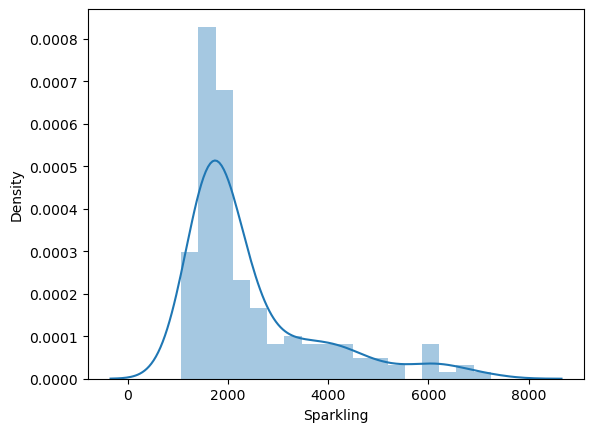

In [11]:
sns.distplot(df['Sparkling'])
plt.show() 

<Axes: >

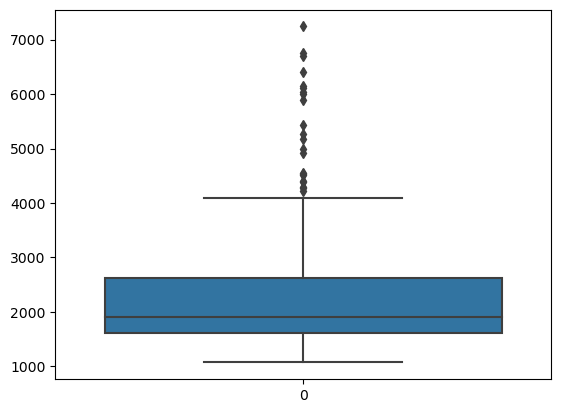

In [12]:
# Univariate Analysis - Boxplot
sns.boxplot(data=df['Sparkling'])

In [13]:
# Imputing outliers in Sparkling with Median Value
df['Sparkling'] = np.where(df['Sparkling']>4000, 1874,df['Sparkling'])

In [14]:
# extract out the time-series
Sparkling_ts = df['Sparkling']

Text(0, 0.5, 'Sparkling')

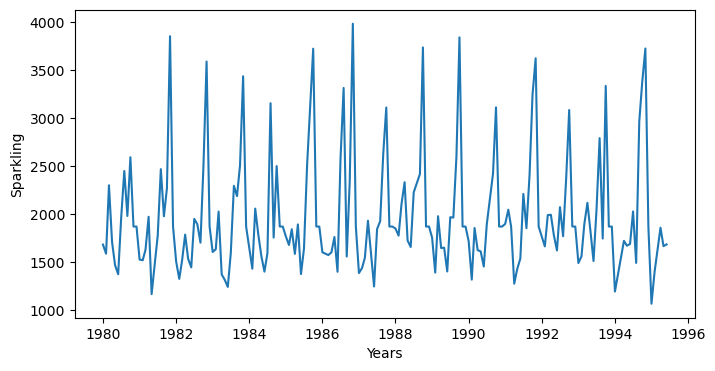

In [15]:
plt.figure(figsize=(8, 4))
plt.plot(Sparkling_ts)
plt.xlabel('Years')
plt.ylabel('Sparkling')


In [16]:
# Dickey-Fuller Test - Dicky Fuller Test on the timeseries is run to check for stationarity of data.

# Null Hypothesis H0: Time Series is non-stationary.
# Alternate Hypothesis Ha: Time Series is stationary.
#So Ideally if p-value < 0.05 then null hypothesis: TS is non-stationary is rejected else 
# the TS is non-stationary is failed to be rejected 
from statsmodels.tsa.stattools import adfuller

In [17]:
dftest = adfuller(Sparkling_ts)#python implementation of dicky fuller test 
dftest
print('DF test statistic is %3.3f' %dftest[0])
print('DF test p-value is %1.4f' %dftest[1])

DF test statistic is -3.360
DF test p-value is 0.0124


In [18]:
# Since p value is less than 0.05, therefore. we reject the Null Hypothesis and Time Series is Stationary.

In [19]:
df=pd.read_csv(r'C:\Users\Anmol\Desktop\Sparkling.csv', parse_dates= True, index_col = 'Year-Month')

In [20]:
# Imputing outliers in Sparkling with Median Value
df['Sparkling'] = np.where(df['Sparkling']>4000, 1874,df['Sparkling'])

In [21]:
#Separate data into train and test
train = df[df.index < '1991']
test  = df[df.index >= '1991']

In [22]:
best_aic = np.inf
best_pdq = None
best_seasonal_pdq = None
temp_model = None

In [23]:
# Simple Exponential Smoothing (Used where there is no trend or seasonality in the data) - ANN Model
# create class
model_SES = SimpleExpSmoothing(train,initialization_method='estimated')

In [24]:
# Fitting the Simple Exponential Smoothing model and asking python to choose the optimal parameters
model_SES_autofit = model_SES.fit(optimized=True)

In [25]:
## Let us check the parameters
model_SES_autofit.params

{'smoothing_level': 0.07532840569702563,
 'smoothing_trend': nan,
 'smoothing_seasonal': nan,
 'damping_trend': nan,
 'initial_level': 1694.7246875463852,
 'initial_trend': nan,
 'initial_seasons': array([], dtype=float64),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

In [26]:
# Using the fitted model on the training set to forecast on the test set
SES_predict = model_SES_autofit.forecast(steps=len(test))
SES_predict

1991-01-01    1990.001781
1991-02-01    1990.001781
1991-03-01    1990.001781
1991-04-01    1990.001781
1991-05-01    1990.001781
1991-06-01    1990.001781
1991-07-01    1990.001781
1991-08-01    1990.001781
1991-09-01    1990.001781
1991-10-01    1990.001781
1991-11-01    1990.001781
1991-12-01    1990.001781
1992-01-01    1990.001781
1992-02-01    1990.001781
1992-03-01    1990.001781
1992-04-01    1990.001781
1992-05-01    1990.001781
1992-06-01    1990.001781
1992-07-01    1990.001781
1992-08-01    1990.001781
1992-09-01    1990.001781
1992-10-01    1990.001781
1992-11-01    1990.001781
1992-12-01    1990.001781
1993-01-01    1990.001781
1993-02-01    1990.001781
1993-03-01    1990.001781
1993-04-01    1990.001781
1993-05-01    1990.001781
1993-06-01    1990.001781
1993-07-01    1990.001781
1993-08-01    1990.001781
1993-09-01    1990.001781
1993-10-01    1990.001781
1993-11-01    1990.001781
1993-12-01    1990.001781
1994-01-01    1990.001781
1994-02-01    1990.001781
1994-03-01  

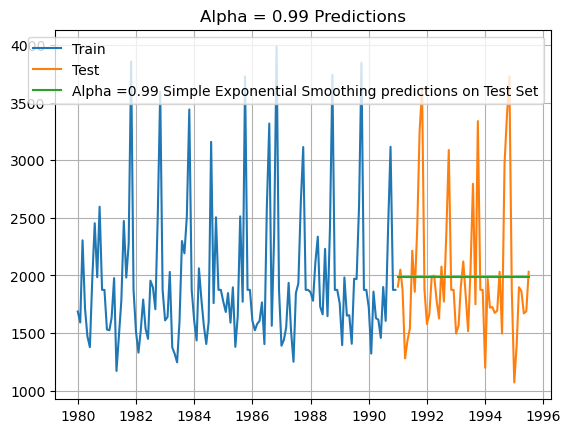

In [27]:
## Plotting the Training data, Test data and the forecasted values

plt.plot(train, label='Train')
plt.plot(test, label='Test')

plt.plot(SES_predict, label='Alpha =0.99 Simple Exponential Smoothing predictions on Test Set')

plt.legend(loc='best')
plt.grid()
plt.title('Alpha = 0.99 Predictions');

In [28]:
# Mean Absolute Percentage Error (MAPE) - Function Definition

def MAPE(y_true, y_pred):
    return np.mean((np.abs(y_true-y_pred))/(y_true))*100

In [29]:
print('SES RMSE:',mean_squared_error(test.values,SES_predict.values,squared=False))
#different way to calculate RMSE
print('SES RMSE (calculated using statsmodels):',em.rmse(test.values,SES_predict.values)[0])

SES RMSE: 592.0734652521055
SES RMSE (calculated using statsmodels): 592.0734652521055


In [30]:
resultsDf = pd.DataFrame({'Test RMSE': [em.rmse(test.values,SES_predict.values)[0]]},index=['Alpha=0.99,SES'])
resultsDf

,Test RMSE
"Alpha=0.99,SES",592.073465


In [31]:
# Initializing the Double Exponential Smoothing Model Holt's Model (AAN Model)
# Applicable whwn Data has Trend but no Seasonality 
model_DES = Holt(train,initialization_method='estimated')
# Fitting the model
model_DES = model_DES.fit()

print('')
print('==Holt model Exponential Smoothing Estimated Parameters ==')
print('')
print(model_DES.params)


==Holt model Exponential Smoothing Estimated Parameters ==

{'smoothing_level': 0.09918642877786256, 'smoothing_trend': 0.09908724234910578, 'smoothing_seasonal': nan, 'damping_trend': nan, 'initial_level': 1505.1410083054318, 'initial_trend': 7.245701216213082, 'initial_seasons': array([], dtype=float64), 'use_boxcox': False, 'lamda': None, 'remove_bias': False}


In [32]:
# Forecasting using this model for the duration of the test set
DES_predict =  model_DES.forecast(len(test))
DES_predict

1991-01-01    1951.873789
1991-02-01    1951.546899
1991-03-01    1951.220009
1991-04-01    1950.893120
1991-05-01    1950.566230
1991-06-01    1950.239340
1991-07-01    1949.912450
1991-08-01    1949.585560
1991-09-01    1949.258670
1991-10-01    1948.931780
1991-11-01    1948.604890
1991-12-01    1948.278000
1992-01-01    1947.951110
1992-02-01    1947.624221
1992-03-01    1947.297331
1992-04-01    1946.970441
1992-05-01    1946.643551
1992-06-01    1946.316661
1992-07-01    1945.989771
1992-08-01    1945.662881
1992-09-01    1945.335991
1992-10-01    1945.009101
1992-11-01    1944.682211
1992-12-01    1944.355322
1993-01-01    1944.028432
1993-02-01    1943.701542
1993-03-01    1943.374652
1993-04-01    1943.047762
1993-05-01    1942.720872
1993-06-01    1942.393982
1993-07-01    1942.067092
1993-08-01    1941.740202
1993-09-01    1941.413312
1993-10-01    1941.086423
1993-11-01    1940.759533
1993-12-01    1940.432643
1994-01-01    1940.105753
1994-02-01    1939.778863
1994-03-01  

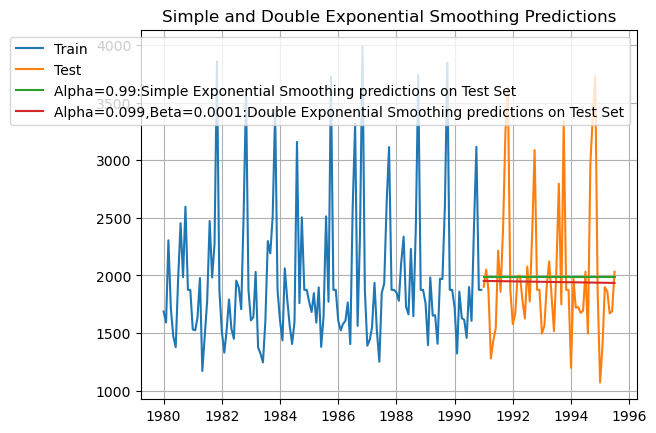

In [33]:
## Plotting the Training data, Test data and the forecasted values

plt.plot(train, label='Train')
plt.plot(test, label='Test')

plt.plot(SES_predict, label='Alpha=0.99:Simple Exponential Smoothing predictions on Test Set')
plt.plot(DES_predict, label='Alpha=0.099,Beta=0.0001:Double Exponential Smoothing predictions on Test Set')

plt.legend(loc='best')
plt.grid()
plt.title('Simple and Double Exponential Smoothing Predictions');



In [34]:
print('DES RMSE:',mean_squared_error(test.values,DES_predict.values,squared=False))

DES RMSE: 594.973216282265


In [35]:
resultsDf_temp = pd.DataFrame({'Test RMSE': [mean_squared_error(test.values,DES_predict.values,squared=False)]}
                           ,index=['Alpha=1,Beta=0.0189:DES'])

resultsDf = pd.concat([resultsDf, resultsDf_temp])
resultsDf

,Test RMSE
"Alpha=0.99,SES",592.073465
"Alpha=1,Beta=0.0189:DES",594.973216


In [36]:
# Initializing the Doubl
seasonal_period=12
model_TES = ExponentialSmoothing(train, trend='additive',seasonal='additive', seasonal_periods= seasonal_period, initialization_method='estimated')
# Fitting the model
model_TES = model_TES.fit()

print('')
print('==Holt Winters model Exponential Smoothing Estimated Parameters ==')
print('')
print(model_TES.params)


==Holt Winters model Exponential Smoothing Estimated Parameters ==

{'smoothing_level': 0.03955104088981798, 'smoothing_trend': 0.03876100515109298, 'smoothing_seasonal': 0.26902844995930586, 'damping_trend': nan, 'initial_level': 1904.2509647562404, 'initial_trend': 0.025756878997009347, 'initial_seasons': array([-344.14898429, -430.93841219, -101.2453189 , -182.69467791,
       -512.45369647, -521.44906216,  -91.66674773,  371.38426538,
         51.09707356,  573.79962423, 1238.50289004,  -42.71010956]), 'use_boxcox': False, 'lamda': None, 'remove_bias': False}


In [37]:
# Forecasting using this model for the duration of the test set
TES_predict =  model_TES.forecast(len(test))
TES_predict

1991-01-01    1653.307912
1991-02-01    1440.557845
1991-03-01    1836.464351
1991-04-01    1739.042443
1991-05-01    1591.449924
1991-06-01    1395.010439
1991-07-01    1928.014511
1991-08-01    1990.466287
1991-09-01    2270.323234
1991-10-01    3184.981967
1991-11-01    2135.811711
1991-12-01    1825.132746
1992-01-01    1635.498461
1992-02-01    1422.748394
1992-03-01    1818.654901
1992-04-01    1721.232993
1992-05-01    1573.640473
1992-06-01    1377.200988
1992-07-01    1910.205061
1992-08-01    1972.656837
1992-09-01    2252.513784
1992-10-01    3167.172516
1992-11-01    2118.002260
1992-12-01    1807.323296
1993-01-01    1617.689011
1993-02-01    1404.938943
1993-03-01    1800.845450
1993-04-01    1703.423542
1993-05-01    1555.831023
1993-06-01    1359.391538
1993-07-01    1892.395610
1993-08-01    1954.847386
1993-09-01    2234.704333
1993-10-01    3149.363066
1993-11-01    2100.192810
1993-12-01    1789.513845
1994-01-01    1599.879560
1994-02-01    1387.129493
1994-03-01  

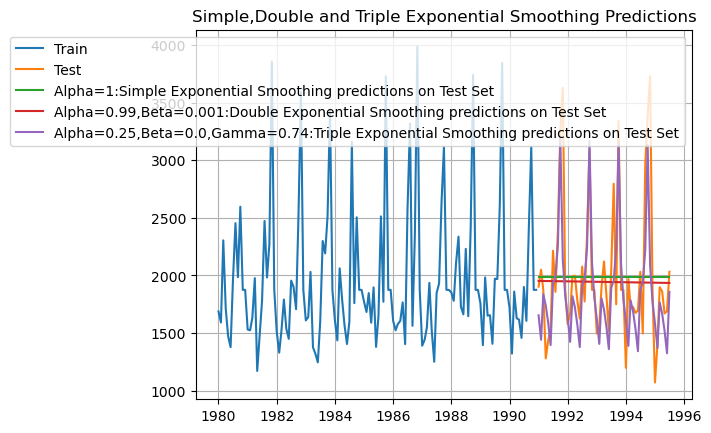

In [38]:
## Plotting the Training data, Test data and the forecasted values

plt.plot(train, label='Train')
plt.plot(test, label='Test')

plt.plot(SES_predict, label='Alpha=1:Simple Exponential Smoothing predictions on Test Set')
plt.plot(DES_predict, label='Alpha=0.99,Beta=0.001:Double Exponential Smoothing predictions on Test Set')
plt.plot(TES_predict, label='Alpha=0.25,Beta=0.0,Gamma=0.74:Triple Exponential Smoothing predictions on Test Set')

plt.legend(loc='best')
plt.grid()
plt.title('Simple,Double and Triple Exponential Smoothing Predictions');

In [39]:
print('TES RMSE:',mean_squared_error(test.values,TES_predict.values,squared=False))

TES RMSE: 417.22401678963377


In [40]:
resultsDf_temp = pd.DataFrame({'Test RMSE': [mean_squared_error(test.values,TES_predict.values,squared=False)]}
                           ,index=['Alpha=0.25,Beta=0.0,Gamma=0.74:TES'])

resultsDf = pd.concat([resultsDf, resultsDf_temp])
resultsDf

,Test RMSE
"Alpha=0.99,SES",592.073465
"Alpha=1,Beta=0.0189:DES",594.973216
"Alpha=0.25,Beta=0.0,Gamma=0.74:TES",417.224017


In [41]:
# Holt Winters - AAM Method
# Initializing the Double Exponential Smoothing Model
seasonal_period=12
model_TES_am = ExponentialSmoothing(train,trend='add',seasonal='multiplicative',seasonal_periods= seasonal_period, initialization_method='estimated')
# Fitting the model
model_TES_am = model_TES_am.fit()

print('')
print('==Holt Winters model Exponential Smoothing Estimated Parameters ==')
print('')
print(model_TES_am.params)


==Holt Winters model Exponential Smoothing Estimated Parameters ==

{'smoothing_level': 0.04035824815090047, 'smoothing_trend': 0.032286559972508996, 'smoothing_seasonal': 0.2741838116998117, 'damping_trend': nan, 'initial_level': 1896.704274831019, 'initial_trend': -7.6518402524718185, 'initial_seasons': array([0.91590679, 0.8185313 , 1.042593  , 0.98512982, 0.74933674,
       0.7282553 , 1.00907637, 1.32079173, 1.06880037, 1.47122118,
       1.66167251, 1.02912263]), 'use_boxcox': False, 'lamda': None, 'remove_bias': False}


In [42]:
# Forecasting using this model for the duration of the test set
TES_predict_am =  model_TES_am.forecast(len(test))
TES_predict_am

1991-01-01    1659.907121
1991-02-01    1449.454610
1991-03-01    1839.741784
1991-04-01    1744.461862
1991-05-01    1599.476188
1991-06-01    1404.162679
1991-07-01    1929.117407
1991-08-01    1992.995773
1991-09-01    2267.548546
1991-10-01    3164.521210
1991-11-01    2130.805549
1991-12-01    1828.361768
1992-01-01    1647.164480
1992-02-01    1438.320432
1992-03-01    1825.600510
1992-04-01    1731.044368
1992-05-01    1587.165958
1992-06-01    1393.348727
1992-07-01    1914.251052
1992-08-01    1977.627283
1992-09-01    2250.051668
1992-10-01    3140.087392
1992-11-01    2114.342636
1992-12-01    1814.226479
1993-01-01    1634.421840
1993-02-01    1427.186253
1993-03-01    1811.459237
1993-04-01    1717.626874
1993-05-01    1574.855728
1993-06-01    1382.534775
1993-07-01    1899.384698
1993-08-01    1962.258794
1993-09-01    2232.554790
1993-10-01    3115.653574
1993-11-01    2097.879724
1993-12-01    1800.091190
1994-01-01    1621.679200
1994-02-01    1416.052075
1994-03-01  

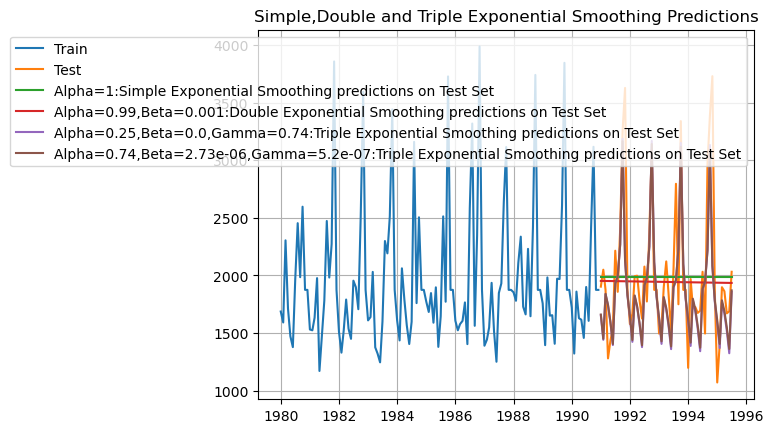

In [43]:
## Plotting the Training data, Test data and the forecasted values

plt.plot(train, label='Train')
plt.plot(test, label='Test')

plt.plot(SES_predict, label='Alpha=1:Simple Exponential Smoothing predictions on Test Set')
plt.plot(DES_predict, label='Alpha=0.99,Beta=0.001:Double Exponential Smoothing predictions on Test Set')
plt.plot(TES_predict, label='Alpha=0.25,Beta=0.0,Gamma=0.74:Triple Exponential Smoothing predictions on Test Set')
plt.plot(TES_predict_am, label='Alpha=0.74,Beta=2.73e-06,Gamma=5.2e-07:Triple Exponential Smoothing predictions on Test Set')

plt.legend(loc='best')
plt.grid()
plt.title('Simple,Double and Triple Exponential Smoothing Predictions');

In [44]:
print('TES_am RMSE:',mean_squared_error(test.values,TES_predict_am.values,squared=False))

TES_am RMSE: 415.19419835589997


In [45]:
resultsDf_temp = pd.DataFrame({'Test RMSE': [mean_squared_error(test.values,TES_predict_am.values,squared=False)]}
                           ,index=['Alpha=0.74,Beta=2.73e-06,Gamma=5.2e-07,Gamma=0:TES'])

resultsDf = pd.concat([resultsDf, resultsDf_temp])
resultsDf

,Test RMSE
"Alpha=0.99,SES",592.073465
"Alpha=1,Beta=0.0189:DES",594.973216
"Alpha=0.25,Beta=0.0,Gamma=0.74:TES",417.224017
"Alpha=0.74,Beta=2.73e-06,Gamma=5.2e-07,Gamma=0:TES",415.194198


In [46]:
print(train.shape)
print(test.shape)

(132, 1)
(55, 1)


In [47]:
# Model 1 Linear Regression
train_time = [i+1 for i in range(len(train))]
test_time = [i+127 for i in range(len(test))]
print('Training Time instance','\n',train_time)
print('Test Time instance','\n',test_time)

Training Time instance 
 [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132]
Test Time instance 
 [127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181]


In [48]:
LinearRegression_train = train.copy()
LinearRegression_test = test.copy()

In [49]:
LinearRegression_train['time'] = train_time
LinearRegression_test['time'] = test_time

print('First few rows of Training Data')
display(LinearRegression_train.head())
print('Last few rows of Training Data')
display(LinearRegression_train.tail())
print('First few rows of Test Data')
display(LinearRegression_test.head())
print('Last few rows of Test Data')
display(LinearRegression_test.tail())

First few rows of Training Data


,Sparkling,time
Year-Month,,
1980-01-01,1686,1
1980-02-01,1591,2
1980-03-01,2304,3
1980-04-01,1712,4
1980-05-01,1471,5


Last few rows of Training Data


,Sparkling,time
Year-Month,,
1990-08-01,1605,128
1990-09-01,2424,129
1990-10-01,3116,130
1990-11-01,1874,131
1990-12-01,1874,132


First few rows of Test Data


,Sparkling,time
Year-Month,,
1991-01-01,1902,127
1991-02-01,2049,128
1991-03-01,1874,129
1991-04-01,1279,130
1991-05-01,1432,131


Last few rows of Test Data


,Sparkling,time
Year-Month,,
1995-03-01,1897,177
1995-04-01,1862,178
1995-05-01,1670,179
1995-06-01,1688,180
1995-07-01,2031,181


In [50]:
from sklearn.linear_model import LinearRegression

In [51]:
lr = LinearRegression()

In [52]:
lr.fit(LinearRegression_train[['time']],LinearRegression_train['Sparkling'])

LinearRegression()

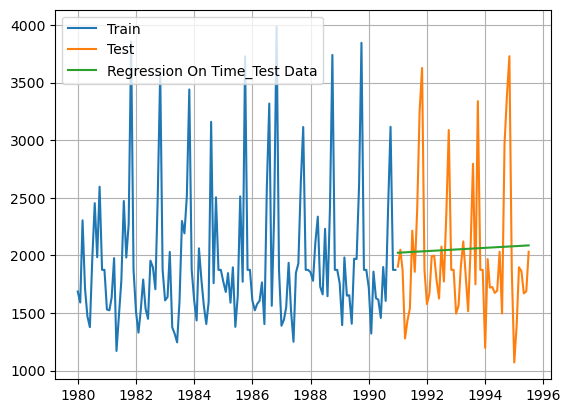

In [53]:
train_predictions_model1         = lr.predict(LinearRegression_train[['time']])
LinearRegression_train['RegOnTime'] = train_predictions_model1

test_predictions_model1         = lr.predict(LinearRegression_test[['time']])
LinearRegression_test['RegOnTime'] = test_predictions_model1

plt.plot( train['Sparkling'], label='Train')
plt.plot(test['Sparkling'], label='Test')
plt.plot(LinearRegression_test['RegOnTime'], label='Regression On Time_Test Data')

plt.legend(loc='best')
plt.grid();


In [54]:
from sklearn import metrics

In [55]:
# Model Evaluation
rmse_model1_test = metrics.mean_squared_error(test['Sparkling'],test_predictions_model1,squared=False)
print("For RegressionOnTime forecast on the Test Data,  RMSE is %3.3f " %(rmse_model1_test))

For RegressionOnTime forecast on the Test Data,  RMSE is 594.585 


In [56]:
resultsDf = pd.DataFrame({'Test RMSE': [rmse_model1_test]},index=['RegressionOnTime'])
resultsDf

,Test RMSE
RegressionOnTime,594.585092


In [57]:
# Model 2 - Naive Approach (yt+1 = yt)
NaiveModel_train = train.copy()
NaiveModel_test = test.copy()

In [58]:
train.tail()

,Sparkling
Year-Month,
1990-08-01,1605
1990-09-01,2424
1990-10-01,3116
1990-11-01,1874
1990-12-01,1874


In [59]:
NaiveModel_test['naive'] = np.asarray(train['Sparkling'])[len(np.asarray(train['Sparkling']))-1]
NaiveModel_test['naive'].head()

Year-Month
1991-01-01    1874
1991-02-01    1874
1991-03-01    1874
1991-04-01    1874
1991-05-01    1874
Name: naive, dtype: int64

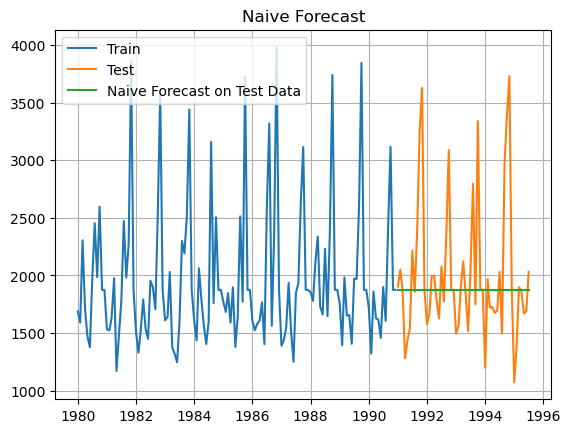

In [60]:
plt.plot(NaiveModel_train['Sparkling'], label='Train')
plt.plot(test['Sparkling'], label='Test')

plt.plot(NaiveModel_test['naive'], label='Naive Forecast on Test Data')

plt.legend(loc='best')
plt.title("Naive Forecast")
plt.grid();

In [61]:
# Model Evaluation
rmse_model2_test = metrics.mean_squared_error(test['Sparkling'],NaiveModel_test['naive'],squared=False)
print("For RegressionOnTime forecast on the Test Data,  RMSE is %3.3f" %(rmse_model2_test))

For RegressionOnTime forecast on the Test Data,  RMSE is 605.922


In [62]:
resultsDf_2 = pd.DataFrame({'Test RMSE': [rmse_model2_test]},index=['NaiveModel'])

resultsDf = pd.concat([resultsDf, resultsDf_2])
resultsDf

,Test RMSE
RegressionOnTime,594.585092
NaiveModel,605.921732


In [63]:
# Model 3 - Simple Average
SimpleAverage_train = train.copy()
SimpleAverage_test = test.copy()

In [64]:
SimpleAverage_test['mean_forecast'] = train['Sparkling'].mean()
SimpleAverage_test.head()

,Sparkling,mean_forecast
Year-Month,,
1991-01-01,1902,1951.318182
1991-02-01,2049,1951.318182
1991-03-01,1874,1951.318182
1991-04-01,1279,1951.318182
1991-05-01,1432,1951.318182


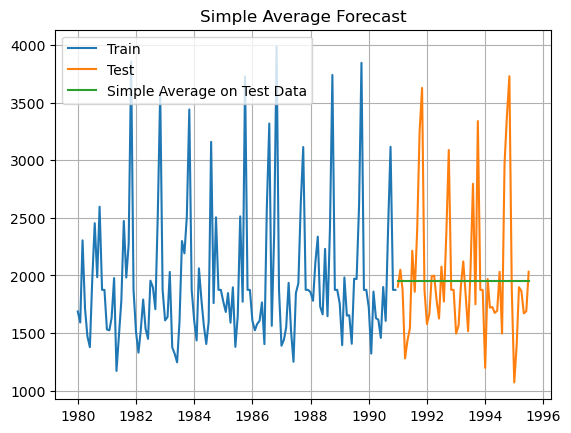

In [65]:
plt.plot(SimpleAverage_train['Sparkling'], label='Train')
plt.plot(SimpleAverage_test['Sparkling'], label='Test')

plt.plot(SimpleAverage_test['mean_forecast'], label='Simple Average on Test Data')

plt.legend(loc='best')
plt.title("Simple Average Forecast")
plt.grid();

In [66]:
# Model Evaluation
rmse_model3_test = metrics.mean_squared_error(test['Sparkling'],SimpleAverage_test['mean_forecast'],squared=False)
print("For Simple Average forecast on the Test Data,  RMSE is %3.3f" %(rmse_model3_test))

For Simple Average forecast on the Test Data,  RMSE is 594.216


In [67]:
resultsDf_3 = pd.DataFrame({'Test RMSE': [rmse_model3_test]}
                           ,index=['SimpleAverageModel'])

resultsDf = pd.concat([resultsDf, resultsDf_3])
resultsDf

,Test RMSE
RegressionOnTime,594.585092
NaiveModel,605.921732
SimpleAverageModel,594.215812


In [68]:
df=pd.read_csv(r'C:\Users\Anmol\Desktop\Sparkling.csv')

In [69]:
# Imputing outliers in Sparkling with Median Value
df['Sparkling'] = np.where(df['Sparkling']>4000, 1874,df['Sparkling'])

In [70]:
# Code to convert/split the data as per frequency
dates = pd.date_range(start='1980-01-01', freq='MS', periods=len(df))

In [71]:
import calendar
df['Month'] = dates.month
df['Month'] = df['Month'].apply(lambda x: calendar.month_abbr[x]) #spltting into english month names 
df['Year'] = dates.year

In [72]:
df.drop(['Year-Month'], axis=1, inplace=True)
df = df[['Month', 'Year', 'Sparkling']]

In [73]:
df.set_index(dates, inplace=True)

In [74]:
df.head(5)

,Month,Year,Sparkling
1980-01-01,Jan,1980,1686
1980-02-01,Feb,1980,1591
1980-03-01,Mar,1980,2304
1980-04-01,Apr,1980,1712
1980-05-01,May,1980,1471


In [75]:
# extract out the time-series
Sparkling_ts = df['Sparkling']

In [76]:
Sparkling_ts_log=np.log(Sparkling_ts)

Text(0, 0.5, 'Sparkling')

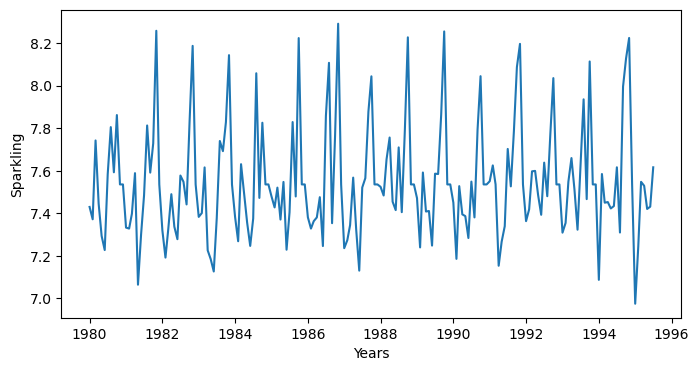

In [77]:
plt.figure(figsize=(8, 4))
plt.plot(Sparkling_ts_log)
plt.xlabel('Years')
plt.ylabel('Sparkling')

In [78]:
# Bivariate Analysis
monthly_sales_data = pd.pivot_table(df, values = "Sparkling", columns = "Year", index = "Month")
monthly_sales_data

Year,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995
Month,,,,,,,,,,,,,,,,
Apr,1712.0,1976.0,1790.0,1375.0,1789.0,1589.0,1605.0,1935.0,2336.0,1650.0,1628.0,1279.0,1997.0,2121.0,1725.0,1862.0
Aug,2453.0,2472.0,1897.0,2298.0,3159.0,2512.0,3318.0,1930.0,1645.0,1968.0,1605.0,1857.0,1773.0,2795.0,1495.0,NaN
Dec,1874.0,1874.0,1874.0,1874.0,1874.0,1874.0,1874.0,1874.0,1874.0,1874.0,1874.0,1874.0,1874.0,1874.0,1874.0,NaN
Feb,1591.0,1523.0,1329.0,1638.0,1435.0,1682.0,1523.0,1442.0,1779.0,1394.0,1321.0,2049.0,1667.0,1564.0,1968.0,1402.0
Jan,1686.0,1530.0,1510.0,1609.0,1609.0,1771.0,1606.0,1389.0,1853.0,1757.0,1720.0,1902.0,1577.0,1494.0,1197.0,1070.0
Jul,1966.0,1781.0,1954.0,1600.0,1597.0,1645.0,2584.0,1847.0,2230.0,1971.0,1899.0,2214.0,2076.0,2048.0,2031.0,2031.0
Jun,1377.0,1480.0,1449.0,1245.0,1404.0,1379.0,1403.0,1250.0,1661.0,1406.0,1457.0,1540.0,1625.0,1515.0,1693.0,1688.0
Mar,2304.0,1633.0,1518.0,2030.0,2061.0,1846.0,1577.0,1548.0,2108.0,1982.0,1859.0,1874.0,1993.0,1898.0,1720.0,1897.0
May,1471.0,1170.0,1537.0,1320.0,1567.0,1896.0,1765.0,1518.0,1728.0,1654.0,1615.0,1432.0,1783.0,1831.0,1674.0,1670.0


In [79]:
monthly_sales_data = monthly_sales_data.reindex(index = ['Jan','Feb','Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
monthly_sales_data

Year,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995
Month,,,,,,,,,,,,,,,,
Jan,1686.0,1530.0,1510.0,1609.0,1609.0,1771.0,1606.0,1389.0,1853.0,1757.0,1720.0,1902.0,1577.0,1494.0,1197.0,1070.0
Feb,1591.0,1523.0,1329.0,1638.0,1435.0,1682.0,1523.0,1442.0,1779.0,1394.0,1321.0,2049.0,1667.0,1564.0,1968.0,1402.0
Mar,2304.0,1633.0,1518.0,2030.0,2061.0,1846.0,1577.0,1548.0,2108.0,1982.0,1859.0,1874.0,1993.0,1898.0,1720.0,1897.0
Apr,1712.0,1976.0,1790.0,1375.0,1789.0,1589.0,1605.0,1935.0,2336.0,1650.0,1628.0,1279.0,1997.0,2121.0,1725.0,1862.0
May,1471.0,1170.0,1537.0,1320.0,1567.0,1896.0,1765.0,1518.0,1728.0,1654.0,1615.0,1432.0,1783.0,1831.0,1674.0,1670.0
Jun,1377.0,1480.0,1449.0,1245.0,1404.0,1379.0,1403.0,1250.0,1661.0,1406.0,1457.0,1540.0,1625.0,1515.0,1693.0,1688.0
Jul,1966.0,1781.0,1954.0,1600.0,1597.0,1645.0,2584.0,1847.0,2230.0,1971.0,1899.0,2214.0,2076.0,2048.0,2031.0,2031.0
Aug,2453.0,2472.0,1897.0,2298.0,3159.0,2512.0,3318.0,1930.0,1645.0,1968.0,1605.0,1857.0,1773.0,2795.0,1495.0,NaN
Sep,1984.0,1981.0,1706.0,2191.0,1759.0,1771.0,1562.0,2638.0,2421.0,2608.0,2424.0,2408.0,2377.0,1749.0,2968.0,NaN


<Axes: xlabel='Month'>

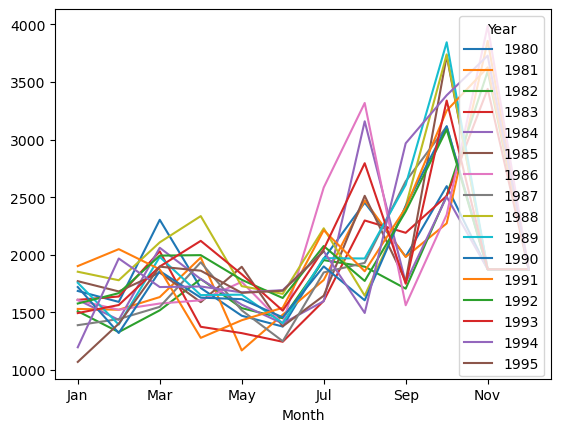

In [80]:
monthly_sales_data.plot()

In [81]:
yearly_sales_data = pd.pivot_table(df, values = "Sparkling", columns = "Month", index = "Year")
yearly_sales_data = yearly_sales_data[['Jan','Feb','Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']]
yearly_sales_data

Month,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
Year,,,,,,,,,,,,
1980,1686.0,1591.0,2304.0,1712.0,1471.0,1377.0,1966.0,2453.0,1984.0,2596.0,1874.0,1874.0
1981,1530.0,1523.0,1633.0,1976.0,1170.0,1480.0,1781.0,2472.0,1981.0,2273.0,3857.0,1874.0
1982,1510.0,1329.0,1518.0,1790.0,1537.0,1449.0,1954.0,1897.0,1706.0,2514.0,3593.0,1874.0
1983,1609.0,1638.0,2030.0,1375.0,1320.0,1245.0,1600.0,2298.0,2191.0,2511.0,3440.0,1874.0
1984,1609.0,1435.0,2061.0,1789.0,1567.0,1404.0,1597.0,3159.0,1759.0,2504.0,1874.0,1874.0
1985,1771.0,1682.0,1846.0,1589.0,1896.0,1379.0,1645.0,2512.0,1771.0,3727.0,1874.0,1874.0
1986,1606.0,1523.0,1577.0,1605.0,1765.0,1403.0,2584.0,3318.0,1562.0,2349.0,3987.0,1874.0
1987,1389.0,1442.0,1548.0,1935.0,1518.0,1250.0,1847.0,1930.0,2638.0,3114.0,1874.0,1874.0
1988,1853.0,1779.0,2108.0,2336.0,1728.0,1661.0,2230.0,1645.0,2421.0,3740.0,1874.0,1874.0


<Axes: xlabel='Year'>

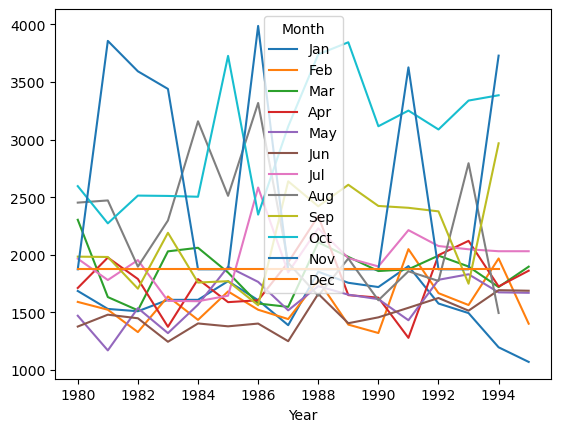

In [82]:
yearly_sales_data.plot()

<Axes: >

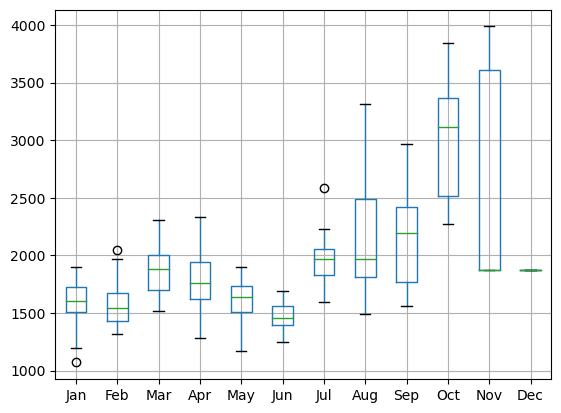

In [83]:
yearly_sales_data.boxplot()

In [84]:
# Time Series Decomposition
decomposition = sm.tsa.seasonal_decompose(Sparkling_ts_log, model='additive')

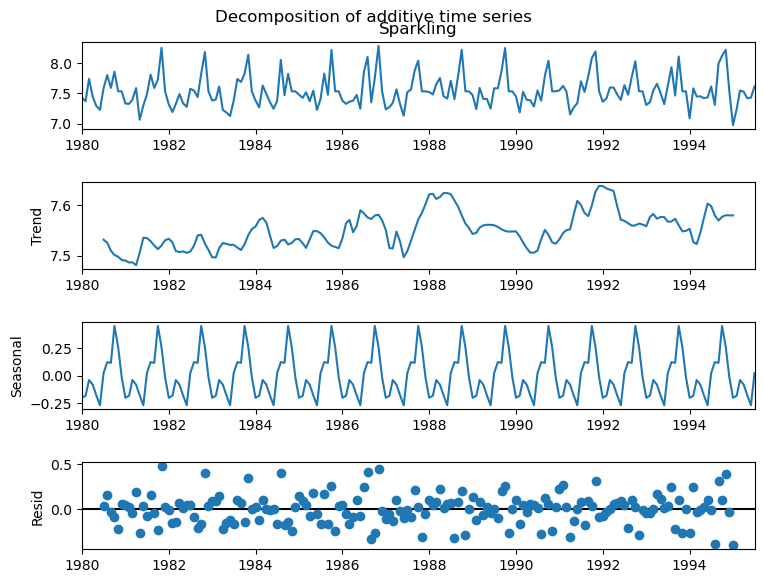

In [85]:
fig = decomposition.plot()
fig.set_figwidth(8)
fig.set_figheight(6)
fig.suptitle('Decomposition of additive time series')
plt.show()

In [86]:
# Time Series Decomposition
decomposition = sm.tsa.seasonal_decompose(Sparkling_ts, model='multiplicative')

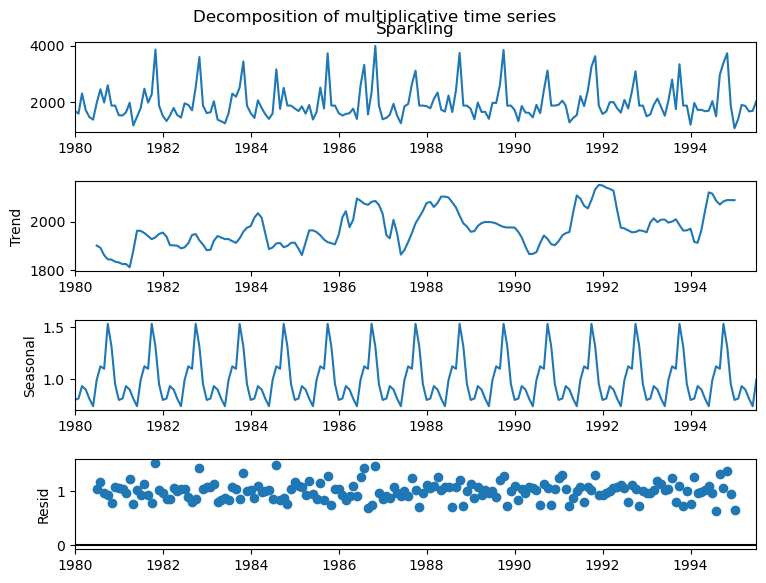

In [87]:
fig = decomposition.plot()
fig.set_figwidth(8)
fig.set_figheight(6)
fig.suptitle('Decomposition of multiplicative time series')
plt.show()

In [88]:
#Separate data into train and test
df['date'] = df.index
train = df[df.index < '1991-01-01']
test = df[df.index >= '1991-01-01']

In [89]:
# AR Model

# Define the p parameter to take any value between 0 and 2
p= range(1,4)


In [90]:
# MA Model

# Define the q parameter to take any value between 0 and 2
q = range(1, 4)


In [91]:
d= range(0,2)

#Generate all different combinations of p with d=0 and q=0 triplets for AR model building
pdq_ar = list(itertools.product(p, range(1), range(1)))

#Generate all different combinations of p,q with d=0 triplets for ARMA model building
pdq_arma = list(itertools.product(p, range(1),q))

#Generate all different combinations of p, d and q triplets for ARIMA model building 
pdq = list(itertools.product(p, d, q))

# Generate all different combinations of seasonal P,D,Q triplets for SARIMA model building
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p, d, q))]

In [92]:
pdq_ar

[(1, 0, 0), (2, 0, 0), (3, 0, 0)]

In [93]:
pdq_arma

[(1, 0, 1),
 (1, 0, 2),
 (1, 0, 3),
 (2, 0, 1),
 (2, 0, 2),
 (2, 0, 3),
 (3, 0, 1),
 (3, 0, 2),
 (3, 0, 3)]

In [94]:
pdq

[(1, 0, 1),
 (1, 0, 2),
 (1, 0, 3),
 (1, 1, 1),
 (1, 1, 2),
 (1, 1, 3),
 (2, 0, 1),
 (2, 0, 2),
 (2, 0, 3),
 (2, 1, 1),
 (2, 1, 2),
 (2, 1, 3),
 (3, 0, 1),
 (3, 0, 2),
 (3, 0, 3),
 (3, 1, 1),
 (3, 1, 2),
 (3, 1, 3)]

In [95]:
seasonal_pdq
# as it seems to have 12 month seasonality as confirmned from above 

[(1, 0, 1, 12),
 (1, 0, 2, 12),
 (1, 0, 3, 12),
 (1, 1, 1, 12),
 (1, 1, 2, 12),
 (1, 1, 3, 12),
 (2, 0, 1, 12),
 (2, 0, 2, 12),
 (2, 0, 3, 12),
 (2, 1, 1, 12),
 (2, 1, 2, 12),
 (2, 1, 3, 12),
 (3, 0, 1, 12),
 (3, 0, 2, 12),
 (3, 0, 3, 12),
 (3, 1, 1, 12),
 (3, 1, 2, 12),
 (3, 1, 3, 12)]

In [96]:
# Using the log transformed series as there is variance in the data
train_Sparkling_ts_log = np.log10(train['Sparkling'])
#Log transformation on the training data to make the time series stationary as we did with full data 

In [97]:
best_aic = np.inf
best_pdq = None
best_seasonal_pdq = None
temp_model = None

In [98]:
# AR Model building to estimate best 'p' ( Lowest AIC Approach )

# Creating an empty Dataframe with column names only
AR_AIC = pd.DataFrame(columns=['param', 'AIC'])
AR_AIC

,param,AIC


In [109]:
from statsmodels.tsa.arima.model import ARIMA

for param in pdq_ar:
    ARIMA_model = ARIMA(train_Sparkling_ts_log,order=param).fit()
    print('ARIMA{} - AIC:{}'.format(param,ARIMA_model.aic))
    AR_AIC = AR_AIC.append({'param':param, 'AIC': ARIMA_model.aic}, ignore_index=True)

ARIMA(1, 0, 0) - AIC:-208.20419625718233
ARIMA(2, 0, 0) - AIC:-207.139655746906
ARIMA(3, 0, 0) - AIC:-205.1989870307516


In [110]:
# Building AR model with best 'p' parameter
best_model = ARIMA(train_Sparkling_ts_log,order = (1,0,0))#p=1 with lowest AIC 
best_results = best_model.fit()

In [111]:
print(best_results.summary().tables[0])
print(best_results.summary().tables[1])

                               SARIMAX Results                                
Dep. Variable:              Sparkling   No. Observations:                  132
Model:                 ARIMA(1, 0, 0)   Log Likelihood                 107.102
Date:                Sun, 28 Jan 2024   AIC                           -208.204
Time:                        10:35:37   BIC                           -199.556
Sample:                    01-01-1980   HQIC                          -204.690
                         - 12-01-1990                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.2744      0.017    198.124      0.000       3.242       3.307
ar.L1          0.2764      0.094      2.929      0.003       0.091       0.461
sigma2         0.0115      0.002      6.723      0.0

In [112]:
# Calculating RMSE for best AR model
pred_dynamic = best_results.get_prediction(start=pd.to_datetime('1990-01-01'), dynamic=True, full_results=True)

In [113]:
pred99 = best_results.get_forecast(steps=len(test), alpha=0.1)#forecasting values 

In [114]:
# Extract the predicted and true values of our time series
Sparkling_sales_forecasted = pred_dynamic.predicted_mean
testCopy1 = test.copy()
testCopy1['Sparkling_sales_forecasted'] = np.power(10, pred99.predicted_mean)

In [115]:
# Compute the root mean square error
mse = ((testCopy1['Sparkling'] - testCopy1['Sparkling_sales_forecasted']) ** 2).mean()
rmse = np.sqrt(mse)
print('The Root Mean Squared Error of our forecasts is {}'.format(round(rmse, 3)))

The Root Mean Squared Error of our forecasts is 604.448


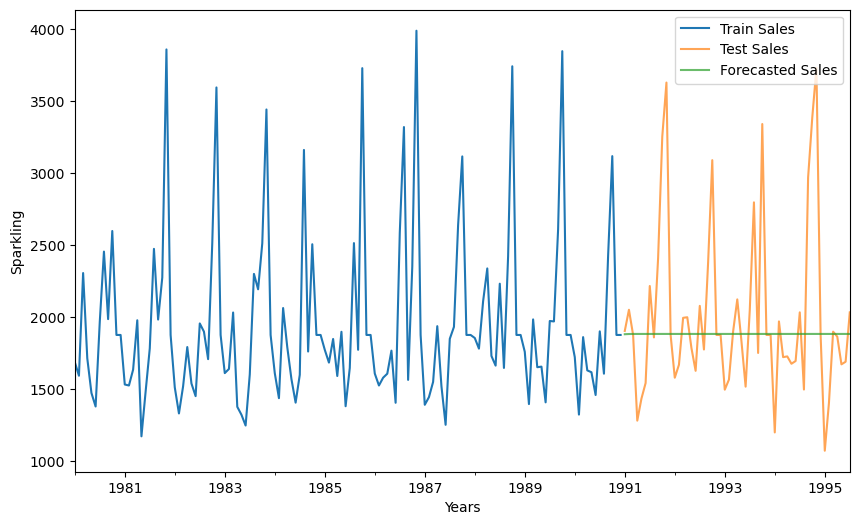

In [116]:
axis = train['Sparkling'].plot(label='Train Sales', figsize=(10, 6))
testCopy1['Sparkling'].plot(ax=axis, label='Test Sales', alpha=0.7)
testCopy1['Sparkling_sales_forecasted'].plot(ax=axis, label='Forecasted Sales', alpha=0.7)
axis.set_xlabel('Years')
axis.set_ylabel('Sparkling')
plt.legend(loc='best')
plt.show()
plt.close()

In [117]:
resultsDf = pd.DataFrame({'RMSE': rmse}
                           ,index=['Best AR Model : ARIMA(1,0,0)'])

resultsDf

,RMSE
"Best AR Model : ARIMA(1,0,0)",604.448405


In [118]:
# ARMA Model building to estimate best 'p' , 'q' ( Lowest AIC Approach )
# Creating an empty Dataframe with column names only
ARMA_AIC = pd.DataFrame(columns=['param', 'AIC'])
ARMA_AIC

,param,AIC


In [119]:
from statsmodels.tsa.arima.model import ARIMA

for param in pdq_arma:
    ARIMA_model = ARIMA(train_Sparkling_ts_log,order=param).fit()
    print('ARIMA{} - AIC:{}'.format(param,ARIMA_model.aic))
    ARMA_AIC =ARMA_AIC.append({'param':param, 'AIC': ARIMA_model.aic}, ignore_index=True)

ARIMA(1, 0, 1) - AIC:-207.59243386719686
ARIMA(1, 0, 2) - AIC:-205.3428422111694
ARIMA(1, 0, 3) - AIC:-206.4816018823079
ARIMA(2, 0, 1) - AIC:-218.9395334192035
ARIMA(2, 0, 2) - AIC:-206.79089430898594
ARIMA(2, 0, 3) - AIC:-203.40514060221668
ARIMA(3, 0, 1) - AIC:-207.38927056124953
ARIMA(3, 0, 2) - AIC:-217.06013973434563
ARIMA(3, 0, 3) - AIC:-232.6344901082625


In [120]:
## Sort the above AIC values in the ascending order to get the parameters for the minimum AIC value

ARMA_AIC.sort_values(by='AIC',ascending=True).head()

,param,AIC
8,"(3, 0, 3)",-232.634490
3,"(2, 0, 1)",-218.939533
7,"(3, 0, 2)",-217.060140
0,"(1, 0, 1)",-207.592434
6,"(3, 0, 1)",-207.389271


In [121]:
# Building ARMA model with best p,q parameter
best_model = ARIMA(train_Sparkling_ts_log,order = (3,0,3))
best_results = best_model.fit()

In [122]:
print(best_results.summary().tables[0])
print(best_results.summary().tables[1])

                               SARIMAX Results                                
Dep. Variable:              Sparkling   No. Observations:                  132
Model:                 ARIMA(3, 0, 3)   Log Likelihood                 124.317
Date:                Sun, 28 Jan 2024   AIC                           -232.634
Time:                        10:36:21   BIC                           -209.572
Sample:                    01-01-1980   HQIC                          -223.263
                         - 12-01-1990                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.2748      0.005    690.960      0.000       3.266       3.284
ar.L1          0.6861      0.178      3.845      0.000       0.336       1.036
ar.L2          0.7234      0.259      2.788      0.0

In [123]:
# Calculating RMSE for best MA model
pred_dynamic = best_results.get_prediction(start=pd.to_datetime('1990-01-01'), dynamic=True, full_results=True)

In [124]:
pred99 = best_results.get_forecast(steps=len(test), alpha=0.1)#forecasting values 

In [125]:
# Extract the predicted and true values of our time series
Sparkling_sales_forecasted = pred_dynamic.predicted_mean
testCopy1 = test.copy()
testCopy1['Sparkling_sales_forecasted'] = np.power(10, pred99.predicted_mean)

In [126]:
# Compute the root mean square error
mse = ((testCopy1['Sparkling'] - testCopy1['Sparkling_sales_forecasted']) ** 2).mean()
rmse = np.sqrt(mse)
print('The Root Mean Squared Error of our forecasts is {}'.format(round(rmse, 3)))

The Root Mean Squared Error of our forecasts is 579.556


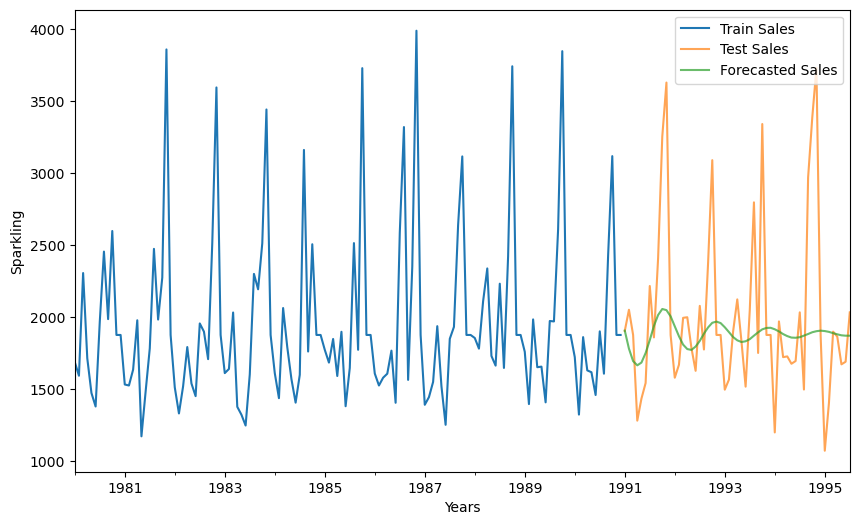

In [127]:
axis = train['Sparkling'].plot(label='Train Sales', figsize=(10, 6))
testCopy1['Sparkling'].plot(ax=axis, label='Test Sales', alpha=0.7)
testCopy1['Sparkling_sales_forecasted'].plot(ax=axis, label='Forecasted Sales', alpha=0.7)
axis.set_xlabel('Years')
axis.set_ylabel('Sparkling')
plt.legend(loc='best')
plt.show()
plt.close()

In [128]:
resultsDf1 = pd.DataFrame({'RMSE': rmse}
                           ,index=['Best ARMA Model : ARIMA(3,0,3)'])

resultsDf1

pd.concat([resultsDf,resultsDf1])

,RMSE
"Best AR Model : ARIMA(1,0,0)",604.448405
"Best ARMA Model : ARIMA(3,0,3)",579.555775


In [129]:
# ARIMA Model building to estimate best 'p' , 'd' , 'q' paramters ( Lowest AIC Approach )
# Creating an empty Dataframe with column names only
ARIMA_AIC = pd.DataFrame(columns=['param', 'AIC'])
ARIMA_AIC

,param,AIC


In [130]:
from statsmodels.tsa.arima.model import ARIMA



In [131]:
for param in pdq:
    ARIMA_model = ARIMA(train_Sparkling_ts_log,order=param).fit()
    print('ARIMA{} - AIC:{}'.format(param,ARIMA_model.aic))
    ARIMA_AIC = ARIMA_AIC.append({'param':param, 'AIC': ARIMA_model.aic}, ignore_index=True)

ARIMA(1, 0, 1) - AIC:-207.59243386719686
ARIMA(1, 0, 2) - AIC:-205.3428422111694
ARIMA(1, 0, 3) - AIC:-206.4816018823079
ARIMA(1, 1, 1) - AIC:-201.35624040647008
ARIMA(1, 1, 2) - AIC:-197.6480599708279
ARIMA(1, 1, 3) - AIC:-202.23462901892276
ARIMA(2, 0, 1) - AIC:-218.9395334192035
ARIMA(2, 0, 2) - AIC:-206.79089430898594
ARIMA(2, 0, 3) - AIC:-203.40514060221668
ARIMA(2, 1, 1) - AIC:-200.13195102797556
ARIMA(2, 1, 2) - AIC:-202.31640583829895
ARIMA(2, 1, 3) - AIC:-200.40962681745293
ARIMA(3, 0, 1) - AIC:-207.38927056124953
ARIMA(3, 0, 2) - AIC:-217.06013973434563
ARIMA(3, 0, 3) - AIC:-232.6344901082625
ARIMA(3, 1, 1) - AIC:-198.1561914647415
ARIMA(3, 1, 2) - AIC:-200.45194255825533
ARIMA(3, 1, 3) - AIC:-201.05071179342318


In [132]:
## Sort the above AIC values in the ascending order to get the parameters for the minimum AIC value

ARIMA_AIC.sort_values(by='AIC',ascending=True).head()

,param,AIC
14,"(3, 0, 3)",-232.634490
6,"(2, 0, 1)",-218.939533
13,"(3, 0, 2)",-217.060140
0,"(1, 0, 1)",-207.592434
12,"(3, 0, 1)",-207.389271


In [133]:
# Building ARIMA model with best parameters p,d,q

best_model = ARIMA(train_Sparkling_ts_log,order = (3,0,3))
best_results = best_model.fit()

In [134]:
print(best_results.summary().tables[0])
print(best_results.summary().tables[1])

                               SARIMAX Results                                
Dep. Variable:              Sparkling   No. Observations:                  132
Model:                 ARIMA(3, 0, 3)   Log Likelihood                 124.317
Date:                Sun, 28 Jan 2024   AIC                           -232.634
Time:                        10:37:37   BIC                           -209.572
Sample:                    01-01-1980   HQIC                          -223.263
                         - 12-01-1990                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.2748      0.005    690.960      0.000       3.266       3.284
ar.L1          0.6861      0.178      3.845      0.000       0.336       1.036
ar.L2          0.7234      0.259      2.788      0.0

In [135]:
# Calculating RMSE for best ARIMA model
pred_dynamic = best_results.get_prediction(start=pd.to_datetime('1990-01-01'), dynamic=True, full_results=True)

In [136]:
pred99 = best_results.get_forecast(steps=len(test), alpha=0.1)#forecasting values 

In [137]:
# Extract the predicted and true values of our time series
Sparkling_sales_forecasted = pred_dynamic.predicted_mean
testCopy1 = test.copy()
testCopy1['Sparkling_sales_forecasted'] = np.power(10, pred99.predicted_mean)

In [138]:
# Compute the root mean square error
mse = ((testCopy1['Sparkling'] - testCopy1['Sparkling_sales_forecasted']) ** 2).mean()
rmse = np.sqrt(mse)
print('The Root Mean Squared Error of our forecasts is {}'.format(round(rmse, 3)))

The Root Mean Squared Error of our forecasts is 579.556


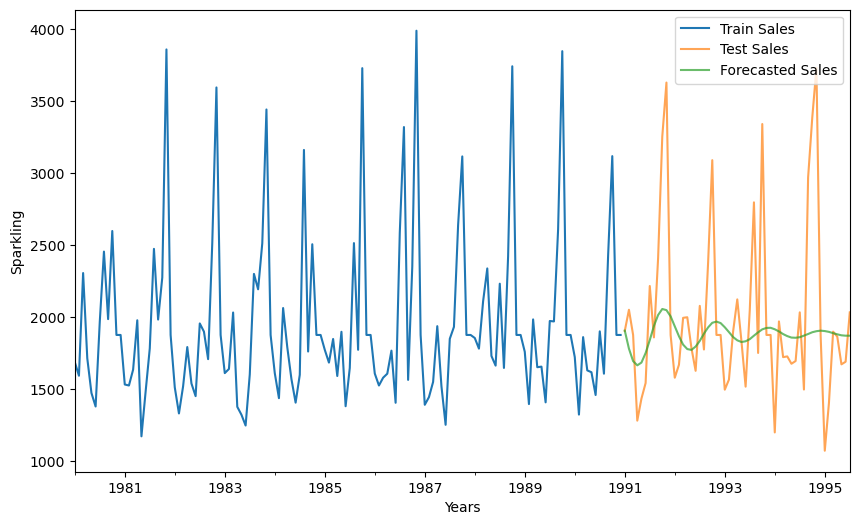

In [139]:
axis = train['Sparkling'].plot(label='Train Sales', figsize=(10, 6))
testCopy1['Sparkling'].plot(ax=axis, label='Test Sales', alpha=0.7)
testCopy1['Sparkling_sales_forecasted'].plot(ax=axis, label='Forecasted Sales', alpha=0.7)
axis.set_xlabel('Years')
axis.set_ylabel('Sparkling')
plt.legend(loc='best')
plt.show()
plt.close()

In [140]:
resultsDf2 = pd.DataFrame({'RMSE': rmse}
                           ,index=['Best ARIMA Model : ARIMA(3,0,3)'])

resultsDf2

pd.concat([resultsDf,resultsDf1,resultsDf2])

,RMSE
"Best AR Model : ARIMA(1,0,0)",604.448405
"Best ARMA Model : ARIMA(3,0,3)",579.555775
"Best ARIMA Model : ARIMA(3,0,3)",579.555775


In [141]:
# SARIMA Model
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


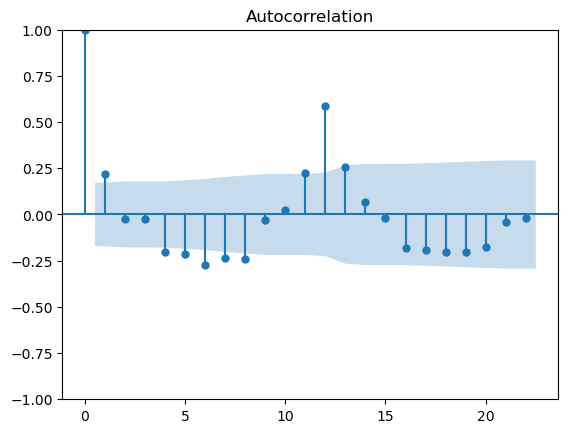

In [142]:
plot_acf(train['Sparkling'],alpha=0.05);

In [143]:
# SARIMA Model building to estimate best parameters
best_aic = np.inf
best_pdq = None
best_seasonal_pdq = None
temp_model = None

In [144]:
SARIMA_AIC = pd.DataFrame(columns=['param','seasonal', 'AIC'])
SARIMA_AIC

,param,seasonal,AIC


In [135]:
import statsmodels.api as sm

for param in pdq:
    for param_seasonal in seasonal_pdq:
        SARIMA_model = sm.tsa.statespace.SARIMAX(train_Sparkling_ts_log,
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            
        results_SARIMA = SARIMA_model.fit(maxiter=1000)
        print('SARIMA{}x{} - AIC:{}'.format(param, param_seasonal, results_SARIMA.aic))
        SARIMA_AIC = SARIMA_AIC.append({'param':param,'seasonal':param_seasonal ,'AIC': results_SARIMA.aic}, ignore_index=True)

SARIMA(1, 0, 1)x(1, 0, 1, 12) - AIC:-249.51269694624847
SARIMA(1, 0, 1)x(1, 0, 2, 12) - AIC:-218.44411921142242
SARIMA(1, 0, 1)x(1, 0, 3, 12) - AIC:3024.3547101028894
SARIMA(1, 0, 1)x(1, 1, 1, 12) - AIC:-223.3655494151008
SARIMA(1, 0, 1)x(1, 1, 2, 12) - AIC:-193.44379754779217
SARIMA(1, 0, 1)x(1, 1, 3, 12) - AIC:2363.5575545732145
SARIMA(1, 0, 1)x(2, 0, 1, 12) - AIC:-222.5323765780587
SARIMA(1, 0, 1)x(2, 0, 2, 12) - AIC:-219.01696830695255
SARIMA(1, 0, 1)x(2, 0, 3, 12) - AIC:2539.371905313828
SARIMA(1, 0, 1)x(2, 1, 1, 12) - AIC:-194.98234917544602
SARIMA(1, 0, 1)x(2, 1, 2, 12) - AIC:-190.64134738421825
SARIMA(1, 0, 1)x(2, 1, 3, 12) - AIC:3547.8284355992305
SARIMA(1, 0, 1)x(3, 0, 1, 12) - AIC:-190.96340873062485
SARIMA(1, 0, 1)x(3, 0, 2, 12) - AIC:-189.187360125834
SARIMA(1, 0, 1)x(3, 0, 3, 12) - AIC:2448.7484473686327
SARIMA(1, 0, 1)x(3, 1, 1, 12) - AIC:-165.96399189482835
SARIMA(1, 0, 1)x(3, 1, 2, 12) - AIC:-164.9079156940776
SARIMA(1, 0, 1)x(3, 1, 3, 12) - AIC:3603.323895202301
SARIM

In [136]:
SARIMA_AIC.sort_values(by=['AIC'],ascending=True).head()

,param,seasonal,AIC
0,"(1, 0, 1)","(1, 0, 1, 12)",-249.512697
18,"(1, 0, 2)","(1, 0, 1, 12)",-246.355744
216,"(3, 0, 1)","(1, 0, 1, 12)",-245.256571
54,"(1, 1, 1)","(1, 0, 1, 12)",-241.462741
36,"(1, 0, 3)","(1, 0, 1, 12)",-241.131061


In [137]:
# Building SARIMA model with the best parameters
best_model = sm.tsa.statespace.SARIMAX(train_Sparkling_ts_log,
                                      order=(1, 0, 1),
                                      seasonal_order=(1, 0, 1, 12),
                                      enforce_stationarity=True)
best_results = best_model.fit()

In [138]:
print(best_results.summary().tables[0])
print(best_results.summary().tables[1])

                                     SARIMAX Results                                      
Dep. Variable:                          Sparkling   No. Observations:                  132
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 12)   Log Likelihood                 134.283
Date:                            Sat, 27 Jan 2024   AIC                           -258.567
Time:                                    22:34:17   BIC                           -244.153
Sample:                                01-01-1980   HQIC                          -252.710
                                     - 12-01-1990                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9996      0.001   1059.626      0.000       0.998       1.001
ma.L1         -0.9487      0.068   

In [139]:
pred_dynamic = best_results.get_prediction(start=pd.to_datetime('1990-01-01'), dynamic=True, full_results=True)

In [140]:
pred99 = best_results.get_forecast(steps=len(test), alpha=0.1)

In [141]:
# Extract the predicted and true values of our time series
Sparkling_sales_forecasted = pred_dynamic.predicted_mean
testCopy = test.copy()
testCopy['Sparkling_sales_forecasted'] = np.power(10, pred99.predicted_mean)

In [142]:
testCopy

,Month,Year,Sparkling,date,Sparkling_sales_forecasted
1991-01-01,Jan,1991,1902,1991-01-01,1672.235721
1991-02-01,Feb,1991,2049,1991-02-01,1468.832620
1991-03-01,Mar,1991,1874,1991-03-01,1835.474946
1991-04-01,Apr,1991,1279,1991-04-01,1738.178581
1991-05-01,May,1991,1432,1991-05-01,1618.976609
1991-06-01,Jun,1991,1540,1991-06-01,1438.157210
1991-07-01,Jul,1991,2214,1991-07-01,1921.384929
1991-08-01,Aug,1991,1857,1991-08-01,1920.469408
1991-09-01,Sep,1991,2408,1991-09-01,2217.045485
1991-10-01,Oct,1991,3252,1991-10-01,3029.021716


In [143]:
#Computing the root mean square error
mse = ((testCopy['Sparkling'] - testCopy['Sparkling_sales_forecasted']) ** 2).mean()
rmse = np.sqrt(mse)
print('The Root Mean Squared Error of our forecasts is {}'.format(round(rmse, 3)))

The Root Mean Squared Error of our forecasts is 435.357


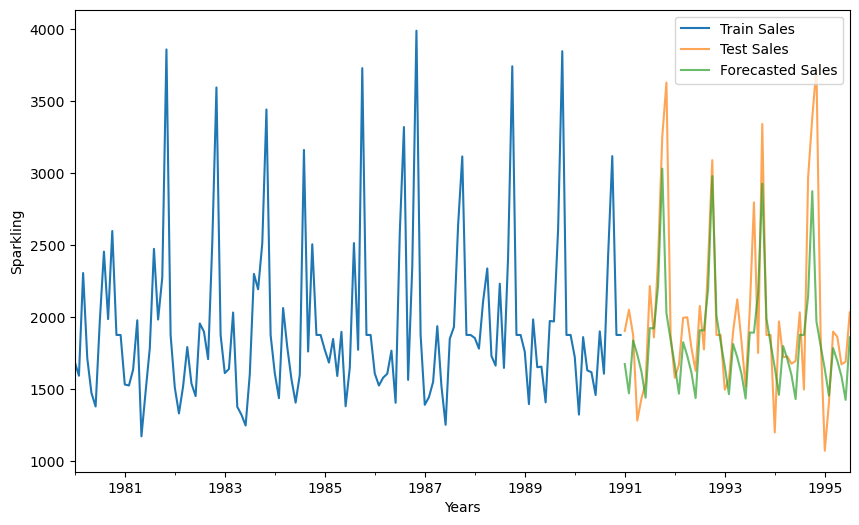

In [144]:
axis = train['Sparkling'].plot(label='Train Sales', figsize=(10, 6))
testCopy['Sparkling'].plot(ax=axis, label='Test Sales', alpha=0.7)
testCopy['Sparkling_sales_forecasted'].plot(ax=axis, label='Forecasted Sales', alpha=0.7)
axis.set_xlabel('Years')
axis.set_ylabel('Sparkling')
plt.legend(loc='best')
plt.show()
plt.close()

In [145]:
resultsDf3 = pd.DataFrame({'RMSE': rmse}
                           ,index=['Best SARIMA Model : SARIMAX(1, 0, 1)x(1, 0, 1, 12)'])

pd.concat([resultsDf,resultsDf1,resultsDf2,resultsDf3])

,RMSE
"Best AR Model : ARIMA(2,0,0)",604.358653
"Best ARMA Model : ARIMA(3,0,3)",579.555775
"Best ARIMA Model : ARIMA(3,0,3)",579.555775
"Best SARIMA Model : SARIMAX(1, 0, 1)x(1, 0, 1, 12)",435.356533


In [146]:
# Forecast sales using the best fit SARIMA model as per RMSE
# Get forecast 12 steps (1 year) ahead in future
n_steps = 12
pred_uc_99 = best_results.get_forecast(steps=12, alpha=0.01) # alpha=0.01 signifies 99% confidence interval
pred_uc_95 = best_results.get_forecast(steps=12, alpha=0.05) # alpha=0.05 95% CI

# Get confidence intervals 95% & 99% of the forecasts
pred_ci_99 = pred_uc_99.conf_int()
pred_ci_95 = pred_uc_95.conf_int()

In [147]:
n_steps = 12
idx = pd.date_range(start='1995-07-31',end='1996-07-31',freq='MS')
fc_95 = pd.DataFrame(np.column_stack([np.power(10, pred_uc_95.predicted_mean), np.power(10, pred_ci_95)]), 
                     index=idx, columns=['forecast', 'lower_ci_95', 'upper_ci_95'])
fc_99 = pd.DataFrame(np.column_stack([np.power(10, pred_ci_99)]), 
                     index=idx, columns=['lower_ci_99', 'upper_ci_99'])
fc_all = fc_95.combine_first(fc_99)
fc_all = fc_all[['forecast', 'lower_ci_95', 'upper_ci_95', 'lower_ci_99', 'upper_ci_99']] # just reordering columns
fc_all

,forecast,lower_ci_95,upper_ci_95,lower_ci_99,upper_ci_99
1995-08-01,1672.235721,1168.875685,2392.360749,1168.875685,2392.360749
1995-09-01,1468.832620,1026.222701,2102.340227,1026.222701,2102.340227
1995-10-01,1835.474946,1281.789376,2628.332191,1281.789376,2628.332191
1995-11-01,1738.178581,1213.282449,2490.157822,1213.282449,2490.157822
1995-12-01,1618.976609,1129.556149,2320.455927,1129.556149,2320.455927
1996-01-01,1438.157210,1002.937232,2062.238886,1002.937232,2062.238886
1996-02-01,1921.384929,1339.313737,2756.426626,1339.313737,2756.426626
1996-03-01,1920.469408,1338.062189,2756.376181,1338.062189,2756.376181
1996-04-01,2217.045485,1543.991402,3183.496151,1543.991402,3183.496151
1996-05-01,3029.021716,2108.504033,4351.413329,2108.504033,4351.413329


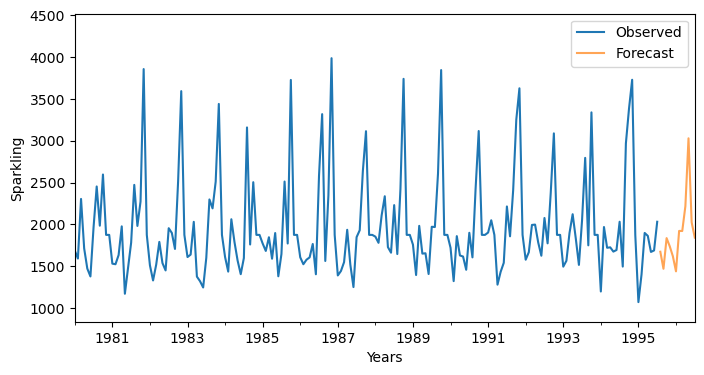

In [148]:
# plot the forecast along with the confidence band

axis = Sparkling_ts.plot(label='Observed', figsize=(8, 4))
fc_all['forecast'].plot(ax=axis, label='Forecast', alpha=0.7)
axis.fill_between(fc_all.index, fc_all['lower_ci_95'], fc_all['upper_ci_95'], color='k', alpha=.15)
axis.set_xlabel('Years')
axis.set_ylabel('Sparkling')
plt.legend(loc='best')
plt.show()

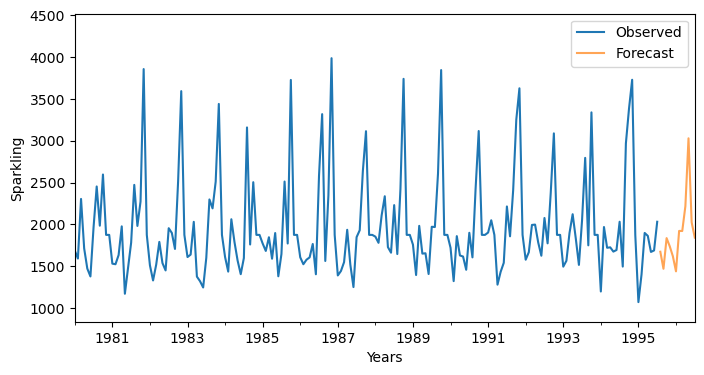

In [149]:
# plot the forecast along with the confidence band

axis = Sparkling_ts.plot(label='Observed', figsize=(8, 4))
fc_all['forecast'].plot(ax=axis, label='Forecast', alpha=0.7)
axis.fill_between(fc_all.index, fc_all['lower_ci_99'], fc_all['upper_ci_99'], color='k', alpha=.15)
axis.set_xlabel('Years')
axis.set_ylabel('Sparkling')
plt.legend(loc='best')
plt.show()

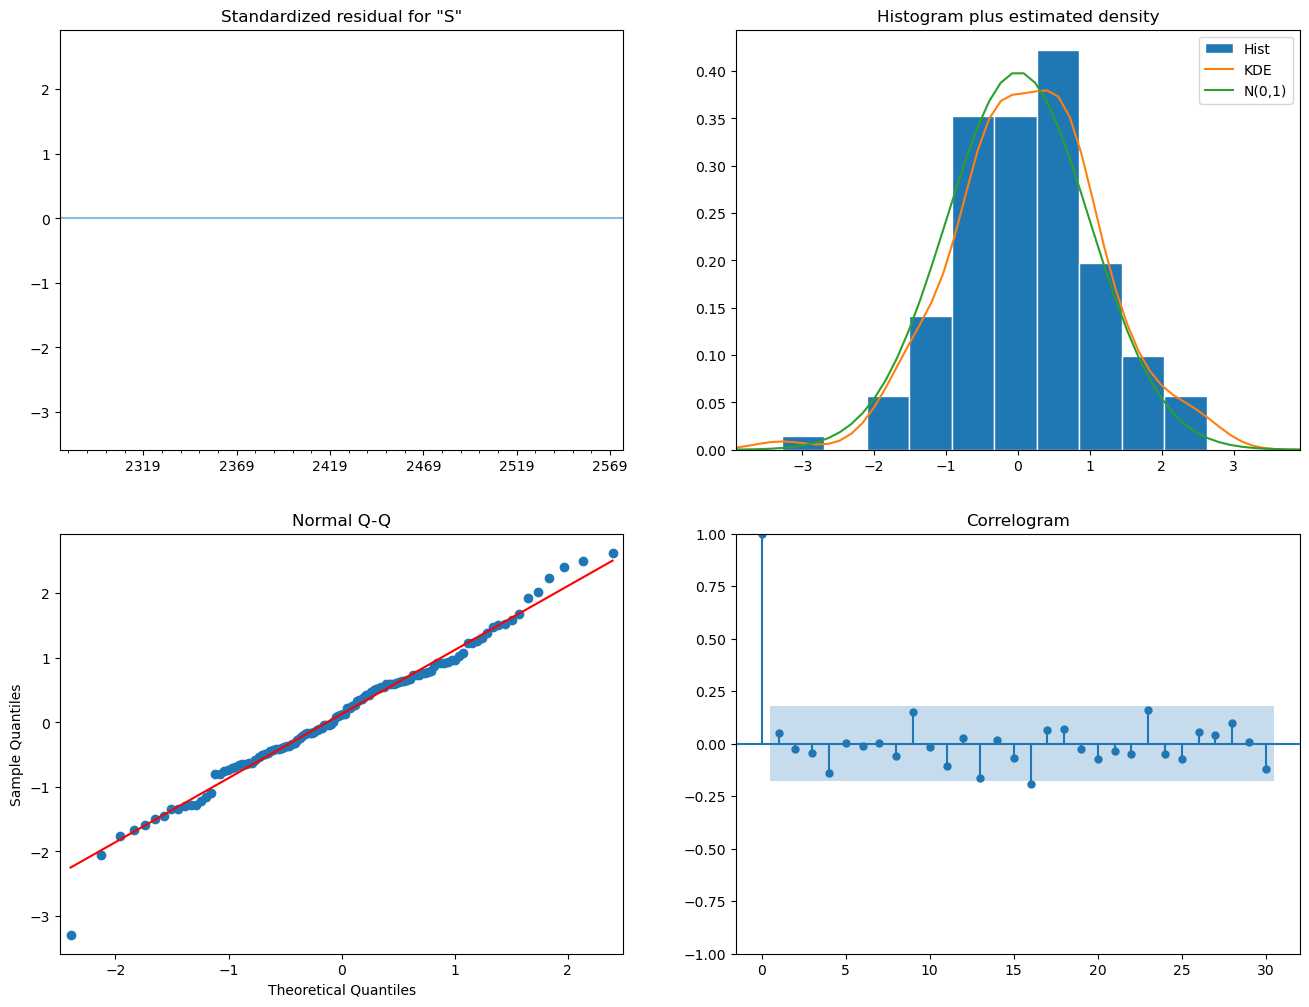

In [515]:
best_results.plot_diagnostics(lags=30, figsize=(16,12))
plt.show()